In [ ]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import des classe et fonctions personnalisées
from tools.OI_class_v2 import OI_DataProcessor
from tools.OI_campagnes import ajouter_element_campagne,reincrementer_campagnes_par_temps
from tools.OI_utils import extract_xls

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [8]:
tags = [ {'tag':'CTY_A1000M_Poids container', 'nom':'A1000M_Poids' },
         {'tag' : 'CTY_A1000M_Teneur arr. Vit. A (UV)', 'nom':'A1000M_UV_Auto' },
         {'tag' :'CTY_A1000M_Titre VA AC', 'nom':'A1000M_Labo' },
         {'tag' :'CTY_A1000M_Numéro Container', 'nom':'A1000M_Num' },
         {'tag' :'CTY_A1000R_Poids container', 'nom':'A1000R_Poids' },
         {'tag' :'CTY_A1000R_Teneur arr. Vit. A (UV)', 'nom':'A1000R_UV_Auto' },
         {'tag' :'CTY_A1000R_Titre VA AC', 'nom':'A1000R_Labo' },
         {'tag' :'CTY_A1000R_Numéro Container', 'nom':'A1000R_Num' },
         {'tag' :'CTY_ACV43A_Rétinène', 'nom':'Rétinène' },
         {'tag' :'FC25207VA', 'nom':'FC25207VA' },
         {'tag' :'CTY_ACV43A_Rapport abs. (350/326)', 'nom':'Acetate_350' },
         {'tag' :'CTY_ACV43A_Teneur Vit. A (UV) ', 'nom':'Acetate_UV' },
         {'tag' :'CV_campagne ', 'nom':'CV_Campagne' },
         {'tag' :'CTY_ACV43A_BHT', 'nom':'BHT' },
         {'tag' :'CTY_FHA1000M_Teneur_VA','nom':'Bat_H_A1000M'},
         {'tag' :'CTY_FHA1000R_Teneur_VA','nom':'Bat_H_A1000R'}
        ]

In [9]:
# Initialisation
processor = OI_DataProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    tags_other = [],
    tags_selected = tags,
    start='2025-01-01',
    end='2025-12-20',
    interval='PT20M',
    verbose=False
)

# Charger les données
processor.merge()

# Appliquer des filtres (chaînage possible)
processor.filtering(
    tag=['A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Labo','A1000R_Poids', 'A1000R_UV_Auto', 'A1000R_Labo','Acetate_UV'],
    min_val=[700, 800_000, 700_000, 700, 800_000, 700_000, 1_500_000],
    max_val=[1500, 1_300_000, 1_300_000, 1500, 1_300_000, 1_300_000, 10_000_000],
    na=['A1000M_Poids','A1000R_Poids']
)

# Ajouter des colonnes
processor.ajoute_cumul('A1000M_Poids', 'A1000M_UV_Auto', 1000, 'Cumul_UV')
processor.ajoute_cumul('A1000M_Poids', 'A1000M_Labo', 1000, 'Cumul_Labo')
processor.ajouter_moyennes_glissantes_ponderee('A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Moyenne_UV', window=15)
processor.ajouter_moyennes_glissantes_ponderee('A1000M_Poids', 'A1000M_Labo', 'A1000M_Moyenne_Labo', window=15)
processor.ajouter_moyennes_glissantes('Acetate_UV', 'Acetate_Moyenne_UV', window=15)

# Afficher les infos finales
processor.info()

INFORMATIONS DataProcessor
URL de base       : https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?
Tags autres       : []
Tags sélectionnés : [{'tag': 'CTY_A1000M_Poids container', 'nom': 'A1000M_Poids'}, {'tag': 'CTY_A1000M_Teneur arr. Vit. A (UV)', 'nom': 'A1000M_UV_Auto'}, {'tag': 'CTY_A1000M_Titre VA AC', 'nom': 'A1000M_Labo'}, {'tag': 'CTY_A1000M_Numéro Container', 'nom': 'A1000M_Num'}, {'tag': 'CTY_A1000R_Poids container', 'nom': 'A1000R_Poids'}, {'tag': 'CTY_A1000R_Teneur arr. Vit. A (UV)', 'nom': 'A1000R_UV_Auto'}, {'tag': 'CTY_A1000R_Titre VA AC', 'nom': 'A1000R_Labo'}, {'tag': 'CTY_A1000R_Numéro Container', 'nom': 'A1000R_Num'}, {'tag': 'CTY_ACV43A_Rétinène', 'nom': 'Rétinène'}, {'tag': 'FC25207VA', 'nom': 'FC25207VA'}, {'tag': 'CTY_ACV43A_Rapport abs. (350/326)', 'nom': 'Acetate_350'}, {'tag': 'CTY_ACV43A_Teneur Vit. A (UV) ', 'nom': 'Acetate_UV'}, {'tag': 'CV_campagne ', 'nom': 'CV_Campagne'}, {'tag': 'CTY_ACV43A_BHT', 'nom': 'BHT'}, {'tag': 'CTY_FHA100

In [ ]:
# 1. On veut changer de date ?
processor.start = '2020-01-01'
processor.end = '2025-12-20'

# 2. On recalcule TOUT (merge + filtres + cumul) en une commande
processor.recalculate()

# 3. On vérifie le pipeline
processor.show_pipeline()

In [10]:
brutes = processor.data.copy()
processor.data = ajouter_element_campagne(brutes)
processor.data['R_Campagne'] = processor.data['R_Campagne'].ffill()
processor.data['M_Campagne'] = processor.data['M_Campagne'].ffill()
brutes = processor.data.copy()
processor.data = reincrementer_campagnes_par_temps(brutes,jours_seuil=10)
processor.data.describe()

,A1000M_Poids,A1000M_UV_Auto,A1000M_Labo,A1000M_Num,A1000R_Poids,A1000R_UV_Auto,A1000R_Labo,A1000R_Num,Rétinène,FC25207VA,Acetate_350,Acetate_UV,BHT,Bat_H_A1000M,Bat_H_A1000R,Cumul_UV,Cumul_Labo,A1000M_Moyenne_UV,A1000M_Moyenne_Labo,Acetate_Moyenne_UV,M_Campagne,R_Campagne,campagne,mois_annee_dt
count,1104.000000,1.225000e+03,1.225000e+03,1046.000000,122.000000,1.225000e+03,1.225000e+03,113.000000,1225.000000,1.225000e+03,1225.000000,1.225000e+03,1225.000000,1.225000e+03,1.225000e+03,1.104000e+03,1.104000e+03,1.022000e+03,1.022000e+03,1.211000e+03,1225.000000,855.000000,1225.000000,1225
mean,1073.843025,1.028510e+06,1.031120e+06,97.628043,1105.549180,1.024728e+06,1.034188e+06,90.876106,0.088639,1.165297e+06,52.167718,2.219828e+06,19.795082,1.019923e+06,1.008980e+06,1.101248e+06,1.104424e+06,1.024696e+06,1.027776e+06,2.220058e+06,3.404082,3.585965,5.802449,2025-05-31 22:35:21.795918336
min,782.000000,9.100000e+05,7.562306e+05,1.000000,919.000000,9.559592e+05,9.249940e+05,1.000000,0.000000,-6.628716e+02,48.100000,2.043305e+06,15.430000,9.864320e+05,9.992720e+05,7.937300e+05,7.936119e+05,9.728129e+05,9.632331e+05,2.043305e+06,1.000000,1.000000,1.000000,2025-01-01 00:00:00
25%,1022.000000,1.014000e+06,1.013022e+06,38.250000,1059.125000,9.790000e+05,1.003422e+06,38.000000,0.010000,1.001836e+06,52.000000,2.185826e+06,18.770000,1.011518e+06,1.003048e+06,1.041313e+06,1.046412e+06,1.011678e+06,1.013017e+06,2.185701e+06,1.000000,3.000000,4.000000,2025-03-01 00:00:00
50%,1070.000000,1.027000e+06,1.030064e+06,94.000000,1109.000000,1.029000e+06,1.037800e+06,81.000000,0.010000,1.349786e+06,52.300000,2.221954e+06,19.990000,1.020142e+06,1.009154e+06,1.098018e+06,1.102055e+06,1.025715e+06,1.028213e+06,2.224646e+06,4.000000,3.000000,6.000000,2025-06-01 00:00:00
75%,1130.000000,1.041000e+06,1.048800e+06,141.000000,1159.250000,1.029000e+06,1.037800e+06,128.000000,0.010000,1.545086e+06,52.500000,2.245983e+06,20.700000,1.026935e+06,1.009154e+06,1.164337e+06,1.165702e+06,1.039205e+06,1.043238e+06,2.244934e+06,5.000000,4.000000,8.000000,2025-09-01 00:00:00
max,1288.000000,1.118000e+06,1.171338e+06,316.000000,1256.000000,1.121000e+06,1.098000e+06,315.000000,2.860000,1.713146e+06,53.000000,2.458167e+06,25.320000,1.054588e+06,1.021662e+06,1.353688e+06,1.418491e+06,1.086901e+06,1.080287e+06,2.458167e+06,7.000000,6.000000,10.000000,2025-12-01 00:00:00
std,78.040431,2.933143e+04,3.121959e+04,67.351551,70.843601,4.274828e+04,2.885511e+04,65.415039,0.340276,4.992205e+05,0.721087,5.197759e+04,1.380402,1.291905e+04,6.237019e+03,8.457297e+04,8.558863e+04,1.954243e+04,2.015099e+04,4.614356e+04,1.968913,1.297372,2.515993,NaN


In [11]:
#processor.plot_tag(tag=['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','FC25207VA','Rétinène','Acetate_UV','BHT','Cumul_UV','A1000M_Moyenne_UV','Acetate_Moyenne_UV'],index= 'campagne')
processor.plot_tag(tag=['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','Acetate_UV','BHT','Cumul_UV','A1000M_Moyenne_UV','Acetate_Moyenne_UV','Bat_H_A1000M','Bat_H_A1000R'],index= 'campagne')

In [ ]:
processor.plot_tag(tag=['A1000R_Poids','A1000R_UV_Auto','A1000R_Labo'],index='R_Campagne')

In [7]:
extract_xls(processor.data,'OI_Analyse_Output',index=True)

Fichier 'OI_Analyse_Output.xlsx' créé avec succès.


<Axes: >

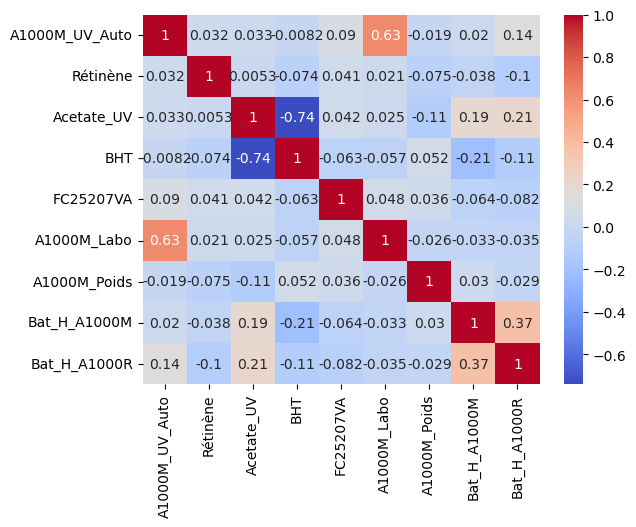

In [12]:
import seaborn as sns
sns.heatmap(processor.data[['A1000M_UV_Auto', 'Rétinène','Acetate_UV','BHT','FC25207VA','A1000M_Labo','A1000M_Poids','Bat_H_A1000M','Bat_H_A1000R']].corr(), annot=True, cmap='coolwarm')